
## Limpieza de datos: pobreza_poblacion_ocupada_sexo.csv obtenido de Cuadro_de_indicadores_ITLP_4T2024.xlsx

El archivo `pobreza_poblacion_ocupada_sexo.csv` contiene el siguiente indicador de pobreza: **Porcentaje de la poblacion Ocupada en pobreza laboral**. Este contempla el porcentaje de la poblacion que se encuentra en pobreza laboral de aquellos que realizan una actividad economica  (ocupados) a nivel nacional, asi como que porcentaje de estos son mujeres y que porcentaje son hombres. Asimismo, indica el ingreso laboral promedio de la poblacion ocupada, el ingreso promedio de los hombres, y el ingreso de las mujeres..

In [12]:
import pandas as pd
import numpy as np

# Saltamos columna vacía
ruta_cruda = '../data/pobreza_poblacion_ocupada_sexo.csv'
columnas_utiles = [2, 3, 5, 6, 7, 9, 10, 11]
nombres_limpios = [
    'anio', 'trimestre', 
    'pobreza_total', 'pobreza_hombres', 'pobreza_mujeres', 
    'ingreso_total', 'ingreso_hombres', 'ingreso_mujeres'
]

In [13]:
# Carga y limpieza de la estructura del dataframe
df_sexo = pd.read_csv(ruta_cruda, skiprows=7, usecols=columnas_utiles, names=nombres_limpios)
df_sexo['anio'] = df_sexo['anio'].ffill()
df_sexo = df_sexo.dropna(subset=['trimestre'])
df_sexo['trimestre'] = df_sexo['trimestre'].replace({'ll*': 'II', 'IV**': 'IV'})
df_sexo = df_sexo.replace({'ND': np.nan, ' ND ': np.nan})

In [14]:
#Limpieza de los formatos monetarios
metricas = [
    'pobreza_total', 'pobreza_hombres', 'pobreza_mujeres', 
    'ingreso_total', 'ingreso_hombres', 'ingreso_mujeres'
]

for col in metricas:
    df_sexo[col] = df_sexo[col].astype(str).str.replace('$', '', regex=False)\
                                           .str.replace(',', '', regex=False)\
                                           .str.strip()
    df_sexo[col] = pd.to_numeric(df_sexo[col].replace('nan', np.nan), errors='coerce')

df_sexo['anio'] = df_sexo['anio'].astype(float).astype('Int64')

In [15]:
#Ultima verificacion de los tipos de datos
print(df_sexo.info())

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   anio             80 non-null     Int64  
 1   trimestre        80 non-null     object 
 2   pobreza_total    79 non-null     float64
 3   pobreza_hombres  79 non-null     float64
 4   pobreza_mujeres  79 non-null     float64
 5   ingreso_total    79 non-null     float64
 6   ingreso_hombres  79 non-null     float64
 7   ingreso_mujeres  79 non-null     float64
dtypes: Int64(1), float64(6), object(1)
memory usage: 5.7+ KB
None


In [16]:
#display de las primeras filas
df_sexo.head(10)

,anio,trimestre,pobreza_total,pobreza_hombres,pobreza_mujeres,ingreso_total,ingreso_hombres,ingreso_mujeres
0,2005,I,16.5,14.0,20.9,6677.89,7421.18,5353.32
1,2005,II,17.1,14.5,21.6,6651.84,7410.56,5356.61
2,2005,III,17.6,15.0,22.1,6618.29,7318.11,5423.90
3,2005,IV,16.1,13.5,20.6,6813.61,7540.13,5587.89
4,2006,I,15.6,13.1,19.8,6851.87,7572.22,5631.87
5,2006,II,15.7,13.3,19.7,6919.19,7654.53,5672.52
6,2006,III,16.4,13.8,20.7,6972.37,7734.31,5698.60
7,2006,IV,16.1,13.5,20.2,6832.15,7593.16,5565.39
8,2007,I,15.5,13.0,19.7,6920.56,7673.48,5661.02
9,2007,II,15.6,13.2,19.5,7018.15,7812.78,5697.51


In [17]:
df_sexo.to_csv('../data/clean_data/pobreza_poblacion_ocupada_sexo_clean.csv',)

# Visualizacion

In [18]:
# Importamos las bibliotecas necesarias de visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Hacemos un mapeo de los trimestres para que tengan formato date
mapping = {'I': '01-01', 'II': '04-01', 'III': '07-01', 'IV': '10-01'}

# Convertimos anio a int y luego a fecha
df_sexo['fecha'] = pd.to_datetime(df_sexo['anio'].astype(int).astype(str) + '-' + df_sexo['trimestre'].map(mapping))

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

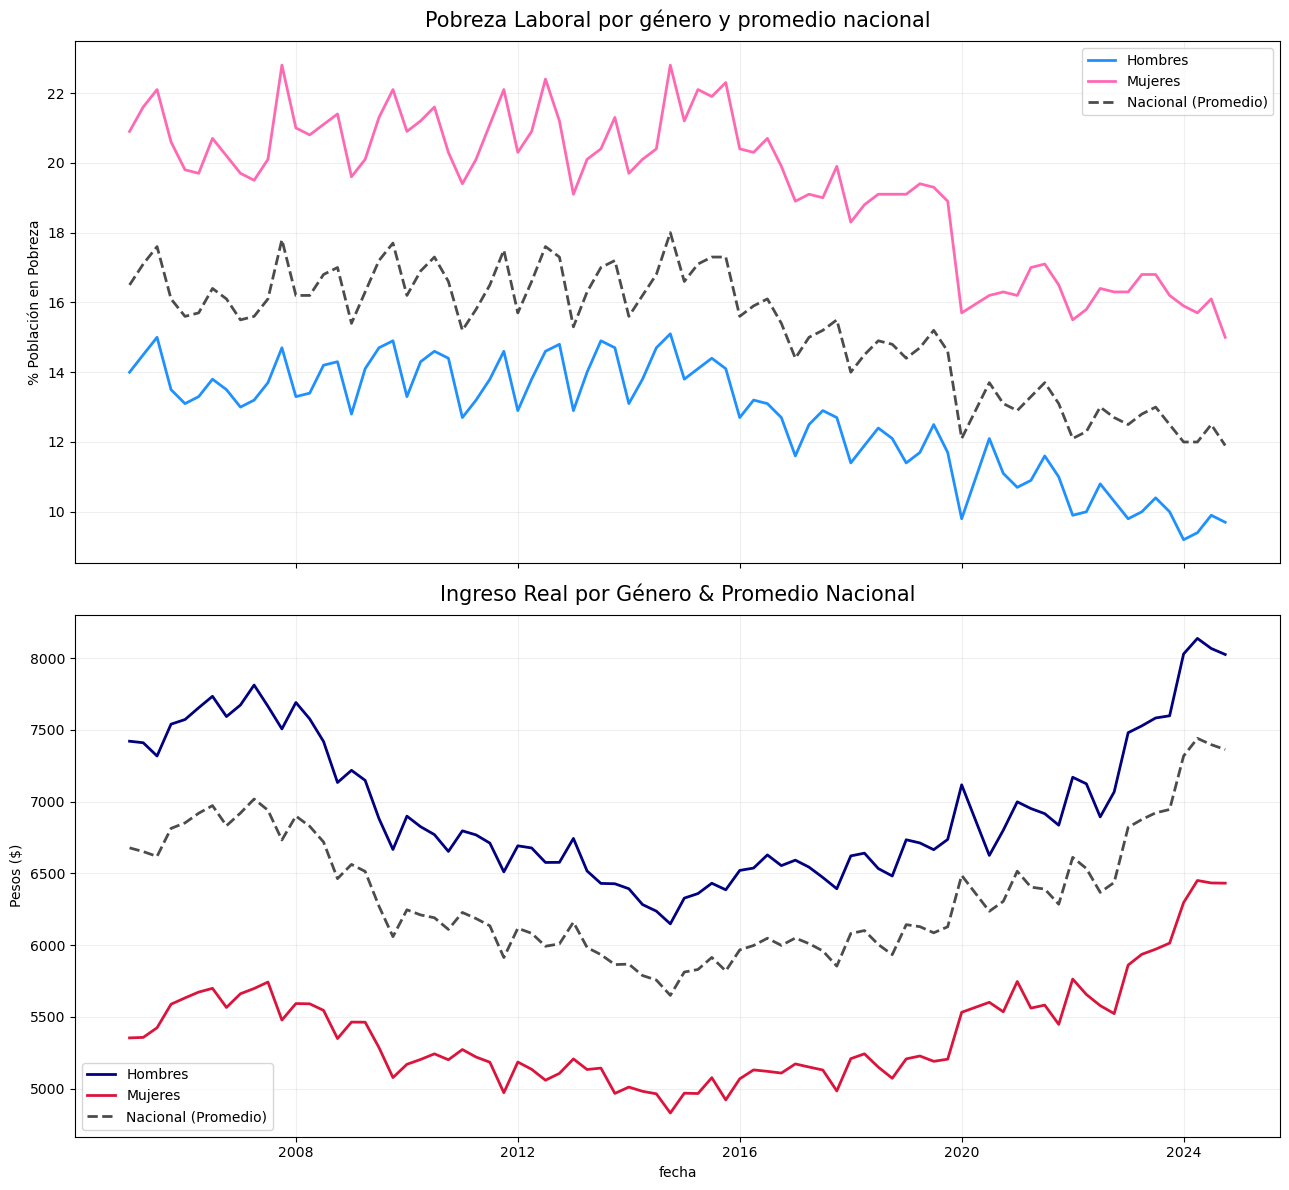

In [21]:
# Configuramos los subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 12), sharex=True)

# --- GRÁFICA DE POBREZA ---
# Líneas de género
sns.lineplot(data=df_sexo, x='fecha', y='pobreza_hombres', ax=ax1, color='dodgerblue', label='Hombres', linewidth=2)
sns.lineplot(data=df_sexo, x='fecha', y='pobreza_mujeres', ax=ax1, color='hotpink', label='Mujeres', linewidth=2)

# Línea Nacional (Referencia)
sns.lineplot(data=df_sexo, x='fecha', y='pobreza_total', ax=ax1, color='black', label='Nacional (Promedio)', 
             linestyle='--', linewidth=2, alpha=0.7)

ax1.set_title('Pobreza Laboral por género y promedio nacional', fontsize=15, pad=10)
ax1.set_ylabel('% Población en Pobreza')
ax1.grid(True, alpha=0.2)
ax1.legend()

# --- GRÁFICA DE INGRESO ---
# Líneas de género
sns.lineplot(data=df_sexo, x='fecha', y='ingreso_hombres', ax=ax2, color='navy', label='Hombres', linewidth=2)
sns.lineplot(data=df_sexo, x='fecha', y='ingreso_mujeres', ax=ax2, color='crimson', label='Mujeres', linewidth=2)

# Línea Nacional (Referencia)
sns.lineplot(data=df_sexo, x='fecha', y='ingreso_total', ax=ax2, color='black', label='Nacional (Promedio)', 
             linestyle='--', linewidth=2, alpha=0.7)

ax2.set_title('Ingreso Real por Género & Promedio Nacional', fontsize=15, pad=10)
ax2.set_ylabel('Pesos ($)')
ax2.grid(True, alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.show()

Observamos que en ambas graficas el promedio nacional (la linea punteada negra) historicamente no solo se acerca, sino que se asemeja mucho mas a la linea azul (la de los hombres), debido a que ellos tienen mayor peso en la fuerza laboral formal, mientras que la linea de las mujeres queda practicamente aislada.

Si bien las graficas nos permiten observar como han evolucionado tanto los ingresos como la pobreza agregada por genero, no ilustra claramente como ha evolucionado la brecha salarial, por ello, calcularemos la proporcion que nos dira *"Por cada 100 pesos que gana un hombre, ¿cuántos gana una mujer?"*

Esta proporcion se calculara bajo la siguiente formula matematica:
$$Proporcion = \dfrac{\text{Ingreso mujeres}}{\text{Ingreso Hombres}}$$

In [ ]:
# Calculamos la proporción (multiplicamos por 100 para verlo como porcentaje)
df_sexo['proporcion_salarial'] = (df_sexo['ingreso_mujeres'] / df_sexo['ingreso_hombres']) * 100

# También podemos calcular el promedio histórico para tener una referencia
promedio_historico = df_sexo['proporcion_salarial'].mean()

c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\valen\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


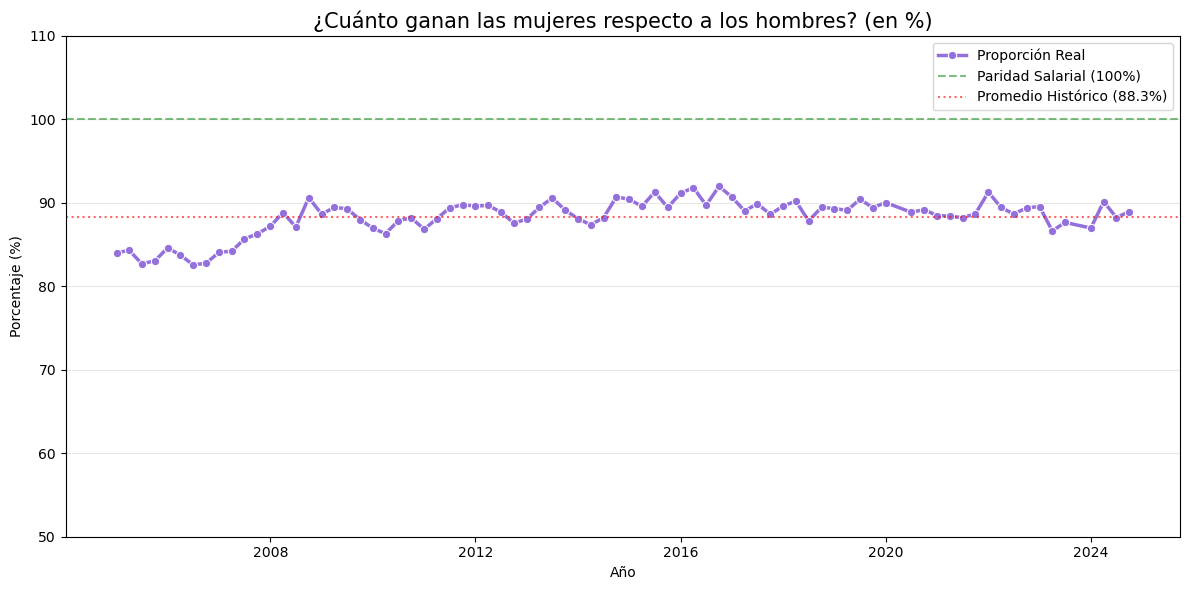

In [ ]:
# Graficamos la evolucion de la equidad
plt.figure(figsize=(12, 6))

# Graficamos la proporción
sns.lineplot(data=df_sexo, x='fecha', y='proporcion_salarial', 
             color='mediumpurple', marker='o', linewidth=2.5, label='Proporción Real')

# Añadimos una línea horizontal en el 100% (Paridad Total)
plt.axhline(100, color='green', linestyle='--', alpha=0.5, label='Paridad Salarial (100%)')

# Añadimos una línea con el promedio histórico
plt.axhline(promedio_historico, color='red', linestyle=':', alpha=0.6, 
            label=f'Promedio Histórico ({promedio_historico:.1f}%)')

plt.title('¿Cuánto ganan las mujeres respecto a los hombres? (en %)', fontsize=15)
plt.ylabel('Porcentaje (%)')
plt.xlabel('Año')
plt.ylim(50, 110) # Ajustamos el eje Y para ver mejor la variación
plt.grid(True, axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()